# 📈 Olist Brazilian E-Commerce Analytics

### **Project Overview**
This project analyzes **100k+ anonymized orders** (2016–2018) from **Olist**, the largest department store integrator in Brazil, to uncover operational trends, predict category growth, and map geographical bottlenecks.

### **Key Insights & Deliverables**
* **🚀 Growth Projections**: Identified high-conviction categories like **Health & Beauty** (+8.92M BRL) and **Watches & Gifts** (+8.12M BRL) as major engines, while flagships like **Toys** face decline.
* **🚚 Logistics & Satisfaction Friction**: Discovered a critical operational drop-off where average reviews plunge from **4.29** (on-time) to **2.27** (late deliveries).
* **🗺️ Interactive Choropleth**: Built an interactive geographical mapping of Brazil's states (`brazil_delivery_map.html`) to visually isolate regional delivery bottlenecks.
* **⚙️ Data Integrity & Quality**: Conducted automated health checks to verify unique PK constraints and assess missing value rates across all transactional tables.

**Data preparation**

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [25]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu, spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sqlite3

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 5)

print("Environment ready.")

Environment ready.


In [ ]:
import kagglehub
import shutil
import glob
import os

# Download the Olist dataset from Kaggle
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset downloaded to:", path)

# Move all CSV files to /content/ so your existing path configuration works
for csv_path in glob.glob(os.path.join(path, "*.csv")):
    shutil.move(csv_path, "/content/" + os.path.basename(csv_path))

print("All dataset files successfully placed in /content/")

100%|██████████| 42.6M/42.6M [00:00<00:00, 61.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
All dataset files successfully placed in /content/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", "{:,.2f}".format)

csv_file = glob.glob("/content/olist_customers_dataset.csv", recursive=True)
BASE = os.path.dirname(csv_file[0]) + "/"
print("BASE =", BASE)

BASE = /content/


In [ ]:
expected = ["olist_orders_dataset.csv", "olist_order_items_dataset.csv",
            "olist_order_payments_dataset.csv", "olist_customers_dataset.csv",
            "olist_order_reviews_dataset.csv", "olist_products_dataset.csv",
            "product_category_name_translation.csv"]
missing = [f for f in expected if not os.path.exists(BASE + f)]
print("Faltando:", missing if missing else "nenhum, todos os arquivos estão lá")

Faltando: ['olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'product_category_name_translation.csv']


In [ ]:
import glob
import os
import pandas as pd

# Search for any of the missing files in the environment to locate the correct directory
possible_paths = glob.glob("**/olist_orders_dataset.csv", recursive=True)
if possible_paths:
    BASE = os.path.dirname(possible_paths[0]) + "/"
else:
    BASE = "/content/"

print(f"Using BASE directory: {BASE}")

try:
    orders = pd.read_csv(BASE + "olist_orders_dataset.csv",
                         parse_dates=["order_purchase_timestamp", "order_approved_at",
                                      "order_delivered_carrier_date", "order_delivered_customer_date",
                                      "order_estimated_delivery_date"])
    order_items = pd.read_csv(BASE + "olist_order_items_dataset.csv")
    payments = pd.read_csv(BASE + "olist_order_payments_dataset.csv")
    customers = pd.read_csv(BASE + "olist_customers_dataset.csv")
    reviews = pd.read_csv(BASE + "olist_order_reviews_dataset.csv")
    products = pd.read_csv(BASE + "olist_products_dataset.csv")

    try:
        translation = pd.read_csv(BASE + "product_category_name_translation.csv")
        has_translation = True
    except FileNotFoundError:
        has_translation = False
        print("Aviso: arquivo de tradução não encontrado. As categorias aparecerão em português.")

    for df, name in [(orders, "orders"), (order_items, "order_items"), (payments, "payments"),
                     (customers, "customers"), (reviews, "reviews"), (products, "products")]:
        print(f"{name}: {df.shape[0]:,} rows | {df.shape[1]} columns")
except FileNotFoundError as e:
    print(f"Erro ao carregar arquivos: {e}")
    print("Por favor, verifique se os datasets foram baixados e extraídos corretamente no ambiente.")

Using BASE directory: /content/
Erro ao carregar arquivos: [Errno 2] No such file or directory: '/content/olist_orders_dataset.csv'
Por favor, verifique se os datasets foram baixados e extraídos corretamente no ambiente.


In [ ]:
import os
import pandas as pd

# Safely load the datasets if they aren't already defined in the namespace
BASE = "/content/"
if 'orders' not in globals():
    print("Loading orders dataset...")
    orders = pd.read_csv(BASE + "olist_orders_dataset.csv",
                         parse_dates=["order_purchase_timestamp", "order_approved_at",
                                      "order_delivered_carrier_date", "order_delivered_customer_date",
                                      "order_estimated_delivery_date"])

if 'payments' not in globals():
    print("Loading payments dataset...")
    payments = pd.read_csv(BASE + "olist_order_payments_dataset.csv")

# Perform the analysis
delivered = orders[orders["order_status"] == "delivered"].copy()

# Sum payment installments into one value per order
payment_per_order = payments.groupby("order_id")["payment_value"].sum().reset_index()
payment_per_order.columns = ["order_id", "order_total"]

# Build the main table
main = delivered.merge(payment_per_order, on="order_id", how="left")
print(f"Delivered orders: {len(main):,}")
print(f"Missing order total: {main['order_total'].isna().sum():,}")

Loading orders dataset...
Loading payments dataset...
Delivered orders: 96,478
Missing order total: 1


**Business overview (KPIs)**

In [ ]:
import pandas as pd

# Safely load the reviews dataset if it is not already defined
BASE = "/content/"
if 'reviews' not in globals():
    print("Loading reviews dataset...")
    reviews = pd.read_csv(BASE + "olist_order_reviews_dataset.csv")

total_orders = len(main)
total_revenue = main["order_total"].sum()
avg_ticket = total_revenue / total_orders
avg_review = reviews.merge(delivered[["order_id"]], on="order_id")["review_score"].mean()

print(f"A) Delivered orders: {total_orders:,}")
print(f"B) Total revenue (BRL): {total_revenue:,.2f}")
print(f"C) Average ticket (BRL): {avg_ticket:,.2f}")
print(f"D) Average review score: {avg_review:.2f}")

Loading reviews dataset...
A) Delivered orders: 96,478
B) Total revenue (BRL): 15,422,461.77
C) Average ticket (BRL): 159.85
D) Average review score: 4.16


**2. Seasonality: orders and revenue over time**

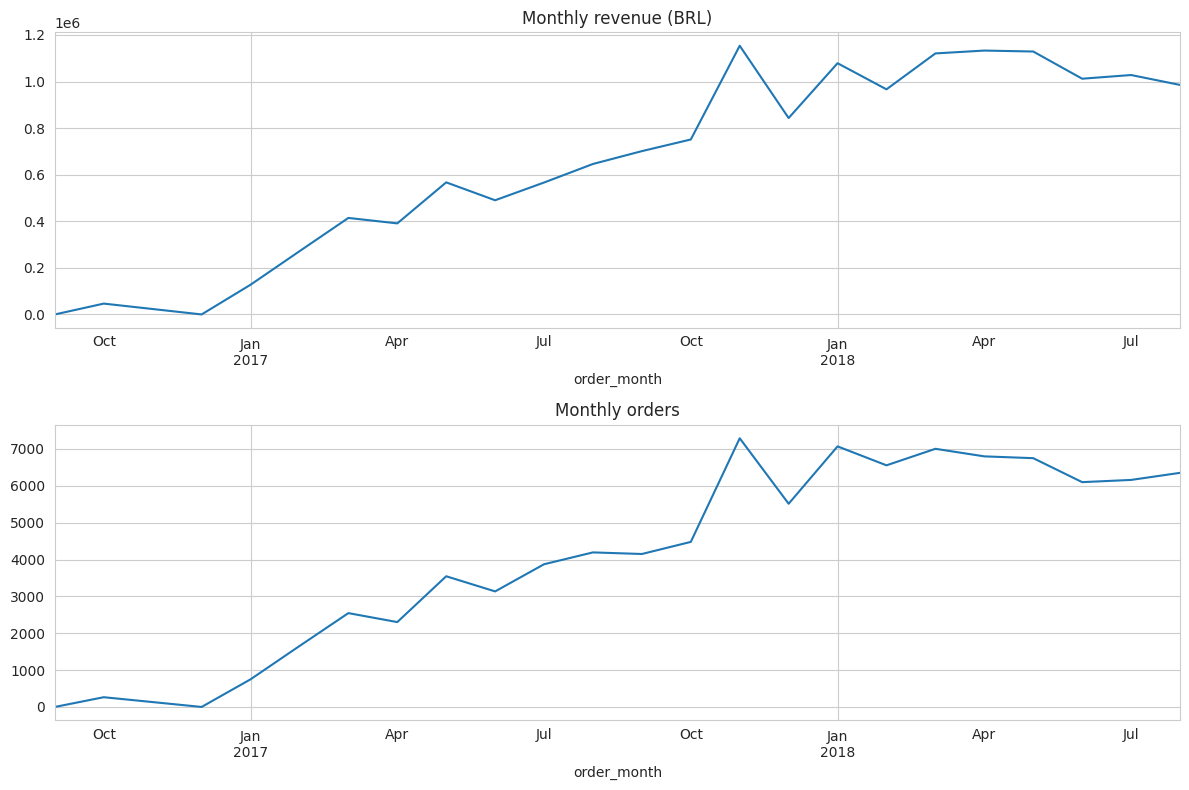

Month with highest revenue: 2017-11
Month with most orders: 2017-11


In [ ]:
main["order_month"] = main["order_purchase_timestamp"].dt.to_period("M")
monthly = main.groupby("order_month").agg(
    revenue=("order_total", "sum"),
    orders=("order_id", "nunique")
)

fig, ax = plt.subplots(2, 1, figsize=(12, 8))
monthly["revenue"].plot(ax=ax[0], title="Monthly revenue (BRL)")
monthly["orders"].plot(ax=ax[1], title="Monthly orders")
plt.tight_layout()
plt.show()

print("Month with highest revenue:", monthly["revenue"].idxmax())
print("Month with most orders:", monthly["orders"].idxmax())

**3. Geographic concentration: states and regions**

In [ ]:
import pandas as pd

# Safely load the customers dataset if it is not already defined
BASE = "/content/"
if 'customers' not in globals():
    print("Loading customers dataset...")
    customers = pd.read_csv(BASE + "olist_customers_dataset.csv")

# Add customer state from the customers table
main = main.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")

state_region = {
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
    "BA": "Northeast", "PE": "Northeast", "CE": "Northeast", "RN": "Northeast",
    "PB": "Northeast", "SE": "Northeast", "AL": "Northeast", "MA": "Northeast",
    "PI": "Northeast",
    "GO": "Central-West", "MT": "Central-West", "MS": "Central-West", "DF": "Central-West",
    "AM": "North", "PA": "North", "RO": "North", "AC": "North", "RR": "North",
    "AP": "North", "TO": "North"
}

main["region"] = main["customer_state"].map(state_region)

revenue_by_state = main.groupby("customer_state")["order_total"].sum().sort_values(ascending=False)
revenue_by_region = main.groupby("region")["order_total"].sum().sort_values(ascending=False)

print("Top 10 states by revenue (BRL):")
print(revenue_by_state.head(10))
print("\nRevenue by region (BRL):")
print(revenue_by_region)

Loading customers dataset...
Top 10 states by revenue (BRL):
customer_state
SP   5,770,266.19
RJ   2,055,690.45
MG   1,819,277.61
RS     861,802.40
PR     781,919.55
SC     595,208.40
BA     591,270.60
DF     346,146.17
GO     334,294.22
ES     317,682.65
Name: order_total, dtype: float64

Revenue by region (BRL):
region
Southeast      9,962,916.90
South          2,238,930.35
Northeast      1,822,936.49
Central-West     996,303.65
North            401,374.38
Name: order_total, dtype: float64


In [ ]:
top2_regions = revenue_by_region.head(2).sum()
print(f"Share of Southeast + South: {top2_regions / total_revenue:.1%}")

top10_states = revenue_by_state.head(10).sum()
print(f"Share of top 10 states: {top10_states / total_revenue:.1%}")

Share of Southeast + South: 79.1%
Share of top 10 states: 87.4%


**4. Delivery performance: where are the bottlenecks?**

In [ ]:
main["delivery_days"] = (main["order_delivered_customer_date"] - main["order_purchase_timestamp"]).dt.days
main["delay_days"] = (main["order_delivered_customer_date"] - main["order_estimated_delivery_date"]).dt.days
main["is_late"] = main["delay_days"] > 0

print(f"Average delivery time (days): {main['delivery_days'].mean():.1f}")
print(f"Late delivery rate: {main['is_late'].mean():.1%}")

by_state_log = main.groupby("customer_state")["delivery_days"].agg(["mean", "count"])
by_state_log = by_state_log[by_state_log["count"] > 100].sort_values("mean", ascending=False)
print("\nStates with the slowest deliveries (avg days):")
print(by_state_log.head(10))

Average delivery time (days): 12.1
Late delivery rate: 6.8%

States with the slowest deliveries (avg days):
                mean  count
customer_state             
AM             25.99    145
AL             24.04    397
PA             23.32    946
MA             21.12    717
SE             21.03    335
CE             20.82   1279
PB             19.95    517
PI             18.99    476
RO             18.91    243
BA             18.87   3256


**5. Customer satisfaction by category**

Loading order_items dataset...
Loading products dataset...
Lowest rated categories (avg score):
category_en
security_and_services              2.50
diapers_and_hygiene                3.38
portable_kitchen_food_processors   3.43
office_furniture                   3.52
pc_gamer                           3.62
home_comfort_2                     3.63
fashion_male_clothing              3.76
fixed_telephony                    3.76
audio                              3.83
party_supplies                     3.83
Name: review_score, dtype: float64


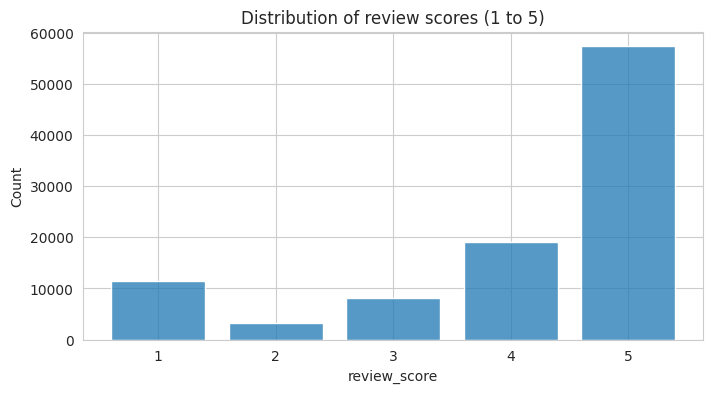

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

BASE = "/content/"

# Safely load required datasets if they are not already defined
if 'order_items' not in globals():
    print("Loading order_items dataset...")
    order_items = pd.read_csv(BASE + "olist_order_items_dataset.csv")

if 'products' not in globals():
    print("Loading products dataset...")
    products = pd.read_csv(BASE + "olist_products_dataset.csv")

if 'translation' not in globals():
    translation_path = BASE + "product_category_name_translation.csv"
    if os.path.exists(translation_path):
        translation = pd.read_csv(translation_path)
        has_translation = True
    else:
        has_translation = False

cat_rev = (reviews
           .merge(delivered[["order_id"]], on="order_id", how="inner")
           .merge(order_items[["order_id", "product_id"]], on="order_id", how="left")
           .merge(products[["product_id", "product_category_name"]], on="product_id", how="left"))

if has_translation:
    cat_rev = cat_rev.merge(translation, on="product_category_name", how="left")
    cat_rev["category_en"] = cat_rev["product_category_name_english"].fillna(cat_rev["product_category_name"])
else:
    cat_rev["category_en"] = cat_rev["product_category_name"]

manual_translation = {
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_processors"
}
cat_rev["category_en"] = cat_rev["category_en"].replace(manual_translation)

score_by_cat = cat_rev.groupby("category_en")["review_score"].mean().sort_values()
print("Lowest rated categories (avg score):")
print(score_by_cat.head(10))

plt.figure(figsize=(8, 4))
sns.histplot(reviews["review_score"], discrete=True, shrink=0.8)
plt.title("Distribution of review scores (1 to 5)")
plt.show()

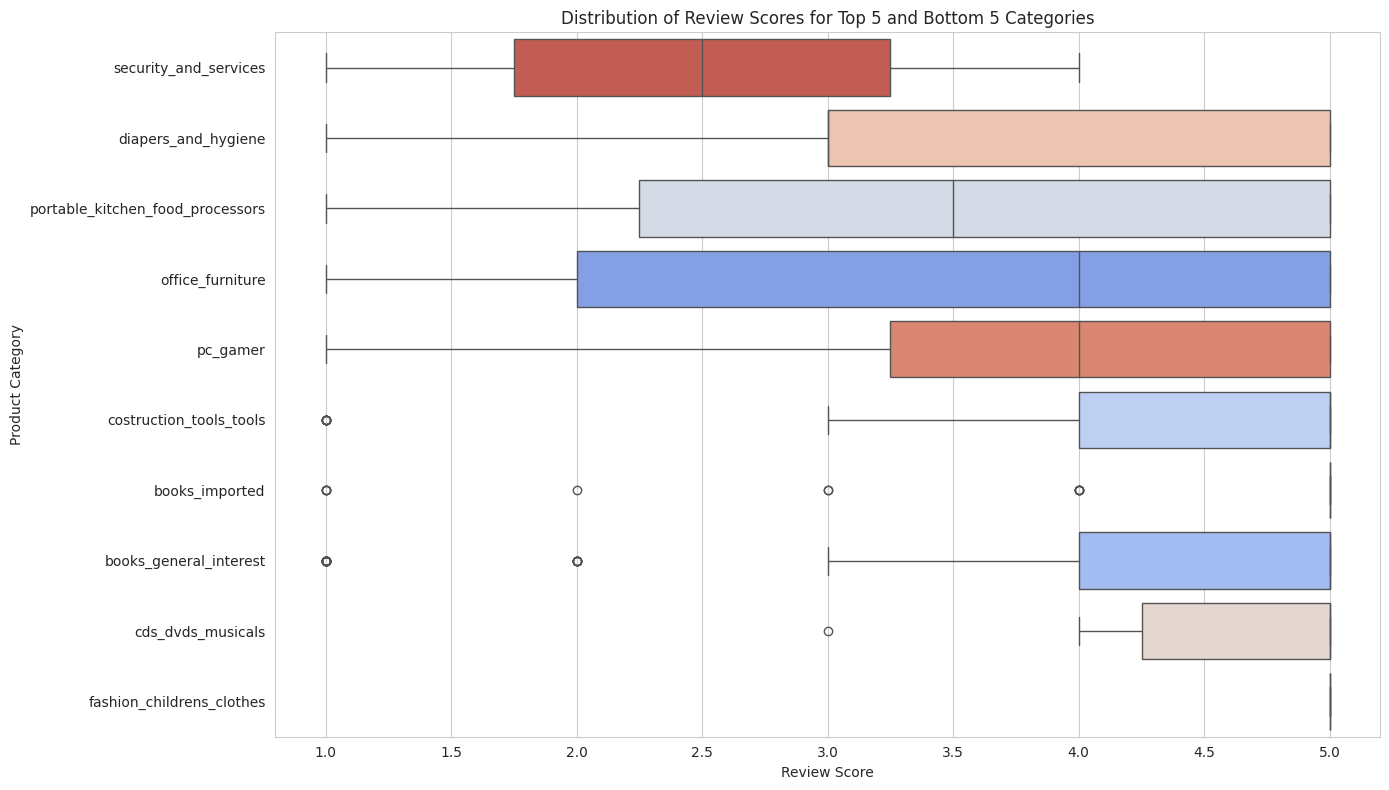

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Let's select the 5 lowest-rated and 5 highest-rated categories to compare their distributions
bottom_5 = score_by_cat.head(5).index.tolist()
top_5 = score_by_cat.tail(5).index.tolist()
selected_categories = bottom_5 + top_5

# Filter the merged cat_rev dataset for these categories
filtered_cat_rev = cat_rev[cat_rev['category_en'].isin(selected_categories)]

# Create a boxplot and a violinplot to see the distribution of scores
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=filtered_cat_rev,
    y='category_en',
    x='review_score',
    order=selected_categories,
    hue='category_en',
    legend=False,
    palette='coolwarm'
)
plt.title("Distribution of Review Scores for Top 5 and Bottom 5 Categories")
plt.xlabel("Review Score")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

,Category Type,Category,Average Freight Value (BRL)
0,Lowest Rated,security_and_services,20.61
1,Lowest Rated,diapers_and_hygiene,14.71
2,Lowest Rated,portable_kitchen_food_processors,20.65
3,Lowest Rated,office_furniture,40.40
4,Lowest Rated,pc_gamer,14.84
5,Highest Rated,costruction_tools_tools,19.77
6,Highest Rated,books_imported,12.83
7,Highest Rated,books_general_interest,16.62
8,Highest Rated,cds_dvds_musicals,16.07
9,Highest Rated,fashion_childrens_clothes,11.94


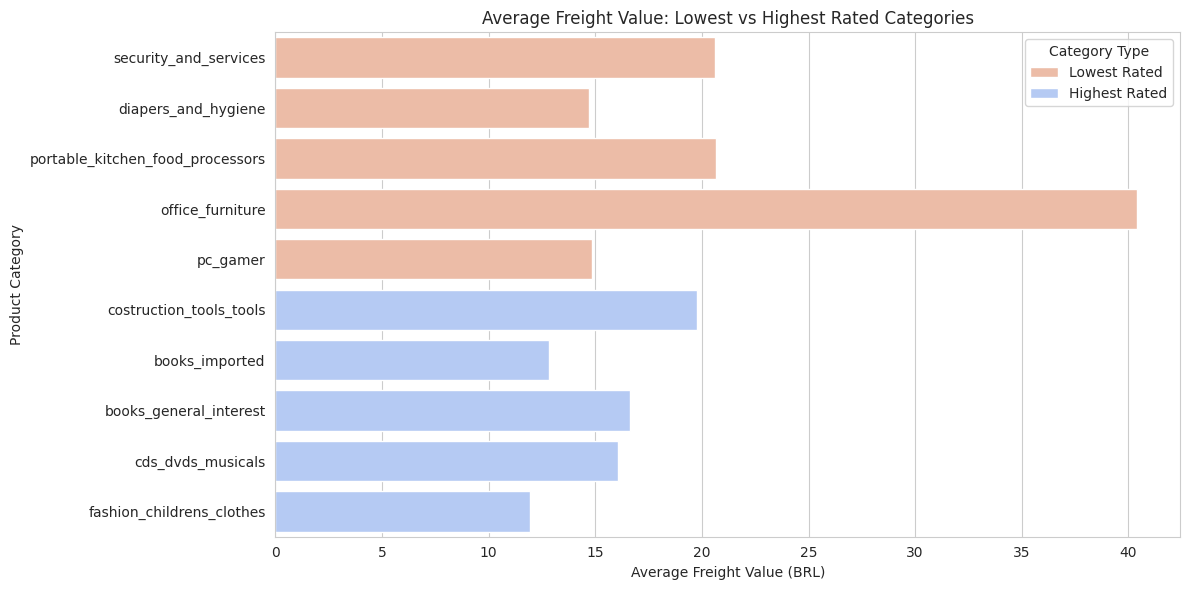

In [ ]:
# Merge order items with reviews and products to get freight values and categories
freight_cat = (
    order_items[['order_id', 'product_id', 'freight_value']]
    .merge(reviews[['order_id']], on='order_id', how='inner')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
)

if has_translation:
    freight_cat = freight_cat.merge(translation, on='product_category_name', how='left')
    freight_cat['category_en'] = freight_cat['product_category_name_english'].fillna(freight_cat['product_category_name'])
else:
    freight_cat['category_en'] = freight_cat['product_category_name']

freight_cat['category_en'] = freight_cat['category_en'].replace(manual_translation)

# Calculate mean freight value by category
avg_freight_by_cat = freight_cat.groupby('category_en')['freight_value'].mean()

# Filter for the target lowest and highest rated categories (bottom_5 and top_5)
compare_freight = pd.DataFrame({
    'Category Type': ['Lowest Rated'] * 5 + ['Highest Rated'] * 5,
    'Category': bottom_5 + top_5,
    'Average Freight Value (BRL)': [avg_freight_by_cat.get(cat, None) for cat in bottom_5 + top_5]
})

display(compare_freight)

# Visualize the comparison
plt.figure(figsize=(12, 6))
sns.barplot(
    data=compare_freight,
    y='Category',
    x='Average Freight Value (BRL)',
    hue='Category Type',
    palette='coolwarm_r'
)
plt.title('Average Freight Value: Lowest vs Highest Rated Categories')
plt.xlabel('Average Freight Value (BRL)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

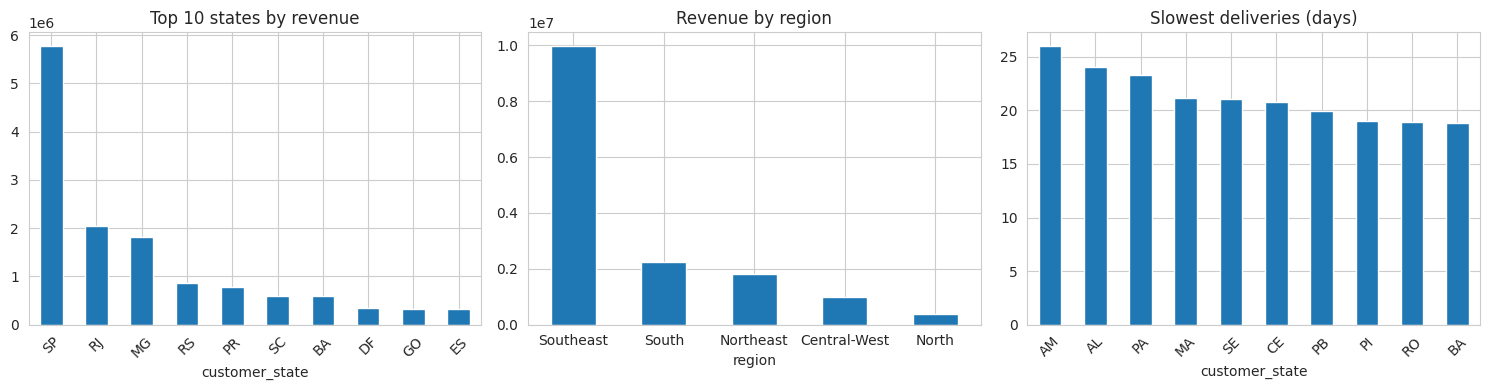

In [ ]:
# Garante que as variáveis existam mesmo se as células anteriores não rodaram
if "by_state_log" not in globals():
    main["delivery_days"] = (main["order_delivered_customer_date"] - main["order_purchase_timestamp"]).dt.days
    main["delay_days"] = (main["order_delivered_customer_date"] - main["order_estimated_delivery_date"]).dt.days
    main["is_late"] = main["delay_days"] > 0
    by_state_log = main.groupby("customer_state")["delivery_days"].agg(["mean", "count"])
    by_state_log = by_state_log[by_state_log["count"] > 100].sort_values("mean", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

revenue_by_state.head(10).plot(kind="bar", ax=axes[0], title="Top 10 states by revenue")
axes[0].tick_params(axis="x", rotation=45)

revenue_by_region.plot(kind="bar", ax=axes[1], title="Revenue by region")
axes[1].tick_params(axis="x", rotation=0)

by_state_log.head(10)["mean"].plot(kind="bar", ax=axes[2], title="Slowest deliveries (days)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Merge delivery performance from 'main' with 'reviews' to analyze their relationship
score_delay_df = main[['order_id', 'delivery_days', 'delay_days', 'is_late']].merge(
    reviews[['order_id', 'review_score']], on='order_id', how='inner'
)

# Drop rows where delivery metrics are missing (e.g., undelivered or canceled orders)
score_delay_clean = score_delay_df.dropna(subset=['delay_days', 'review_score'])

# Calculate Pearson correlation coefficient
correlation = score_delay_clean['delay_days'].corr(score_delay_clean['review_score'])
print(f"Pearson correlation between delivery delay (days) and review score: {correlation:.4f}")

# Calculate average review score for on-time vs late orders
avg_score_by_ontime = score_delay_clean.groupby('is_late')['review_score'].mean().reset_index()
print("\nAverage review score by delivery status (is_late):")
print(avg_score_by_ontime.to_string(index=False))

Pearson correlation between delivery delay (days) and review score: -0.2670

Average review score by delivery status (is_late):
 is_late  review_score
   False          4.29
    True          2.27


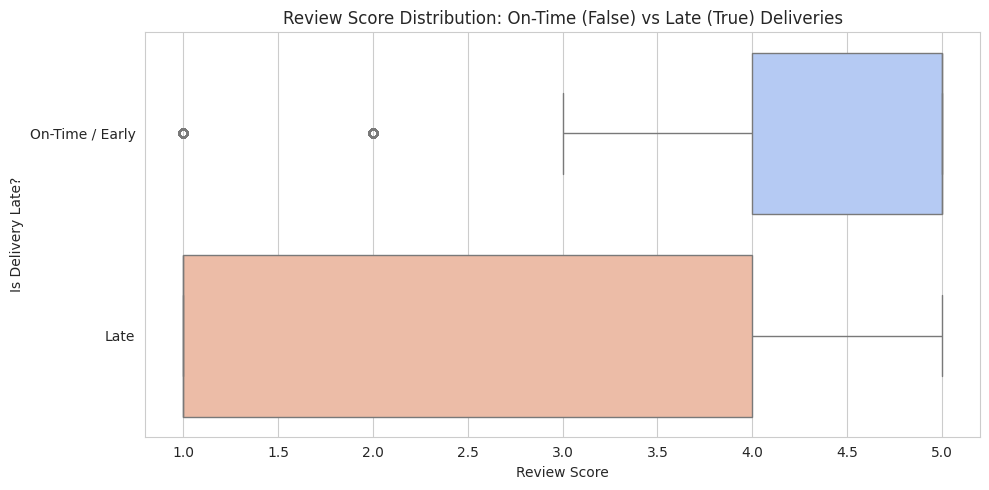

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the relationship with a boxplot showing review score distribution for on-time vs late orders
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=score_delay_clean,
    x='review_score',
    y='is_late',
    orient='h',
    hue='is_late',
    legend=False,
    palette='coolwarm'
)
plt.title('Review Score Distribution: On-Time (False) vs Late (True) Deliveries')
plt.xlabel('Review Score')
plt.ylabel('Is Delivery Late?')
plt.yticks([0, 1], ['On-Time / Early', 'Late'])
plt.tight_layout()
plt.show()

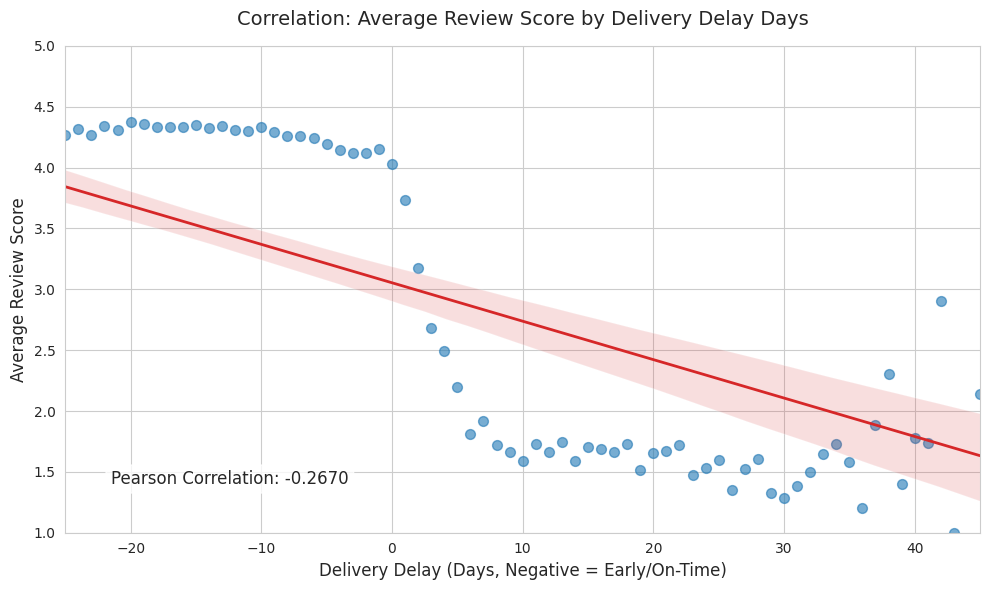

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure we have the cleaned merged dataset of delays and review scores
score_delay_clean = score_delay_df.dropna(subset=['delay_days', 'review_score'])

# Group by delay days to get the average review score for each specific delay day count
# This makes the trend much clearer and less crowded than plotting 90k+ points directly
aggregated_trend = score_delay_clean.groupby('delay_days')['review_score'].agg(['mean', 'count']).reset_index()
# Filter for delay days with a representative number of orders (e.g., at least 5 orders)
aggregated_trend = aggregated_trend[aggregated_trend['count'] >= 5]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Draw a scatter plot of average review scores vs delay days
sns.regplot(
    data=aggregated_trend,
    x='delay_days',
    y='mean',
    scatter_kws={'alpha':0.6, 'color': '#1f77b4', 's': 50},
    line_kws={'color': '#d62728', 'linewidth': 2}
)

# Annotate the correlation coefficient on the plot
correlation_coef = score_delay_clean['delay_days'].corr(score_delay_clean['review_score'])
plt.text(
    0.05, 0.1,
    f"Pearson Correlation: {correlation_coef:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.title('Correlation: Average Review Score by Delivery Delay Days', fontsize=14, pad=15)
plt.xlabel('Delivery Delay (Days, Negative = Early/On-Time)', fontsize=12)
plt.ylabel('Average Review Score', fontsize=12)
plt.xlim(-25, 45) # Zoom in on the most common range of delays
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

Top 5 categories with the highest average delivery delay (days):


,category_en,delay_days
0,arts_and_craftmanship,-6.79
1,furniture_mattress_and_upholstery,-7.16
2,home_comfort_2,-8.43
3,portable_kitchen_food_processors,-9.50
4,pc_gamer,-9.62


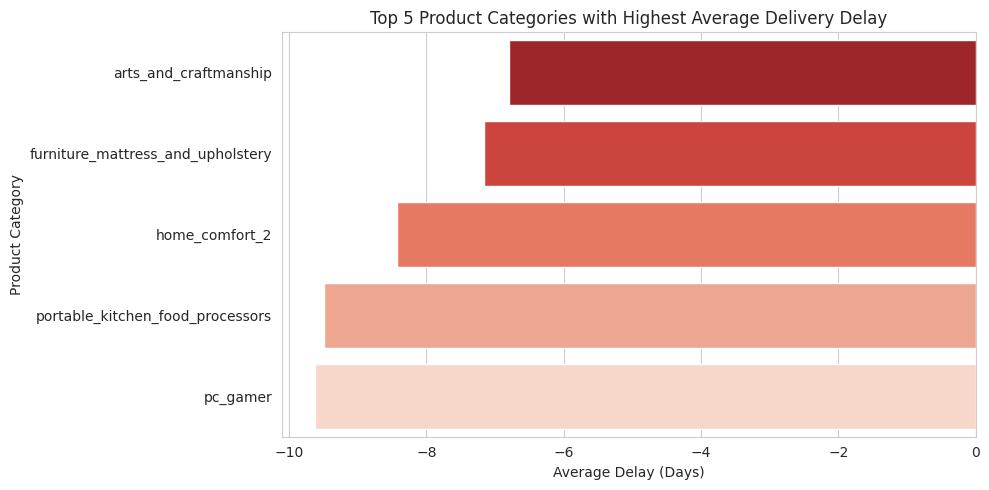

In [ ]:
# Merge main delivery metrics with order items and products
delay_cat = (
    main[['order_id', 'delay_days']]
    .merge(order_items[['order_id', 'product_id']], on='order_id', how='inner')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
)

# Map to English categories
if has_translation:
    delay_cat = delay_cat.merge(translation, on='product_category_name', how='left')
    delay_cat['category_en'] = delay_cat['product_category_name_english'].fillna(delay_cat['product_category_name'])
else:
    delay_cat['category_en'] = delay_cat['product_category_name']

delay_cat['category_en'] = delay_cat['category_en'].replace(manual_translation)

# Calculate mean delay in days by category
avg_delay_by_cat = delay_cat.groupby('category_en')['delay_days'].mean().sort_values(ascending=False).head(5).reset_index()

print("Top 5 categories with the highest average delivery delay (days):")
display(avg_delay_by_cat)

# Visualize the top 5 highest delivery delays
plt.figure(figsize=(10, 5))
sns.barplot(
    data=avg_delay_by_cat,
    x='delay_days',
    y='category_en',
    hue='category_en',
    legend=False,
    palette='Reds_r'
)
plt.title('Top 5 Product Categories with Highest Average Delivery Delay')
plt.xlabel('Average Delay (Days)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=avg_delay_by_cat)

https://docs.google.com/spreadsheets/d/1QFKxqe5fCo9cyXAmbbjPmufU45CjdekGLatlR0rI66c/edit#gid=0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the category dataset with purchase timestamps and totals
cat_sales = (
    order_items[['order_id', 'product_id', 'price']]
    .merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']], on='order_id', how='inner')
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
)

# Filter for delivered orders
cat_sales = cat_sales[cat_sales['order_status'] == 'delivered'].copy()

# Extract year and month
cat_sales['year'] = cat_sales['order_purchase_timestamp'].dt.year

# Map to English categories
if has_translation:
    cat_sales = cat_sales.merge(translation, on='product_category_name', how='left')
    cat_sales['category_en'] = cat_sales['product_category_name_english'].fillna(cat_sales['product_category_name'])
else:
    cat_sales['category_en'] = cat_sales['product_category_name']

cat_sales['category_en'] = cat_sales['category_en'].replace(manual_translation)

# Group sales by category and year
category_yearly = cat_sales.groupby(['category_en', 'year'])['price'].sum().unstack(fill_value=0)

# Filter out categories with very low sales volume to avoid skewing trends (e.g., min 10,000 BRL total revenue)
category_yearly['total_revenue'] = category_yearly.sum(axis=1)
category_yearly = category_yearly[category_yearly['total_revenue'] >= 10000]

# Since 2016 and 2018 have partial data, we will calculate growth from 2017 to a normalized 2018 or use YoY run-rates.
# Let's inspect the actual yearly revenue distribution to set up our forecast.
display(category_yearly.sort_values(by='total_revenue', ascending=False).head(10))

year,2016,2017,2018,total_revenue
category_en,,,,
health_beauty,"3,574.22","473,833.00","755,724.50","1,233,131.72"
watches_gifts,"2,711.07","475,610.71","687,855.20","1,166,176.98"
bed_bath_table,478.99,"490,596.92","532,358.85","1,023,434.76"
sports_leisure,"2,012.15","435,674.14","517,166.26","954,852.55"
computers_accessories,669.02,"391,786.29","496,269.30","888,724.61"
furniture_decor,"5,690.52","324,587.60","381,649.57","711,927.69"
housewares,"1,287.07","222,518.16","391,823.46","615,628.69"
cool_stuff,"1,046.10","381,414.30","227,743.70","610,204.10"
auto,"1,128.26","234,550.09","343,288.30","578,966.65"


,Current Annual Revenue (est),Estimated Annual Growth Rate,Projected Year 3 Revenue,Cumulative 3-Year Gain (BRL)
health_beauty,"1,133,586.75",0.80,"6,611,077.93","8,923,594.90"
watches_gifts,"1,031,782.80",0.80,"6,017,357.29","8,122,194.20"
sports_leisure,"775,749.39",0.78,"4,379,256.90","5,892,752.42"
computers_accessories,"744,403.95",0.80,"4,341,363.84","5,859,947.89"
housewares,"587,735.19",0.80,"3,427,671.63","4,626,651.42"
bed_bath_table,"798,538.28",0.63,"3,443,566.68","4,463,341.88"
furniture_decor,"572,474.36",0.76,"3,140,713.86","4,213,717.77"
auto,"514,932.45",0.80,"3,003,086.05","4,053,548.25"
baby,"375,923.68",0.80,"2,192,386.93","2,959,271.25"
telephony,"261,185.52",0.80,"1,523,233.95","2,056,052.41"


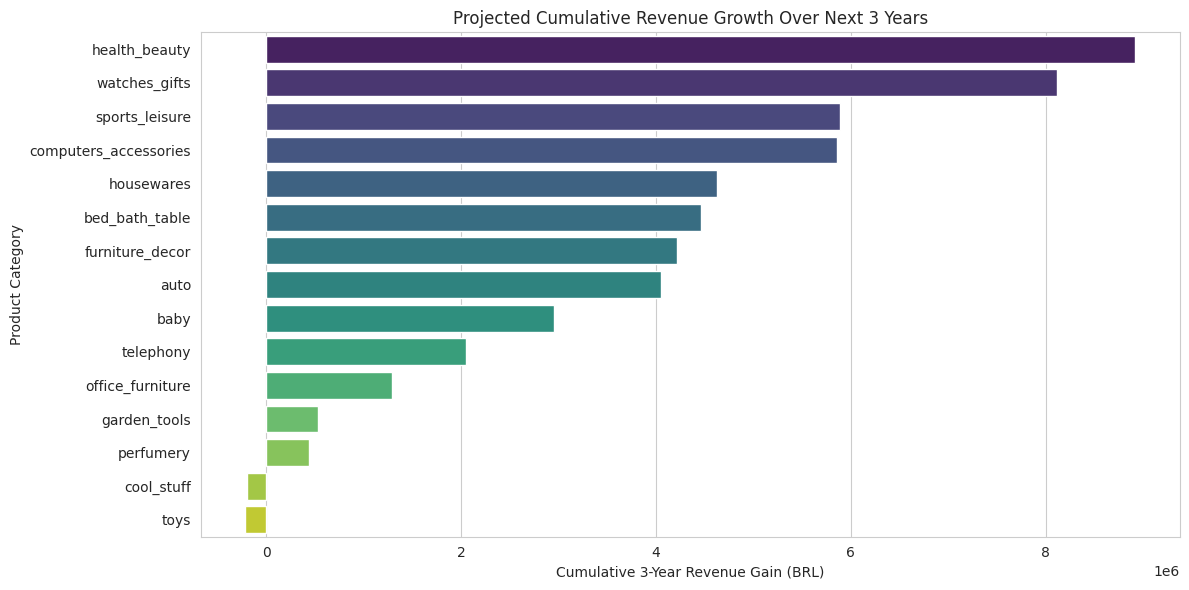

In [ ]:
# Calculate historical monthly sales to build a projection models for each category
cat_monthly = cat_sales.groupby(['category_en', 'year', cat_sales['order_purchase_timestamp'].dt.month])['price'].sum().reset_index(name='monthly_revenue')
cat_monthly.columns = ['category_en', 'year', 'month', 'monthly_revenue']

# Focus on top 15 categories by revenue to find the most sustainable winner
top_categories = category_yearly.sort_values(by='total_revenue', ascending=False).head(15).index.tolist()

# Estimate growth and project next 3 years
future_projections = {}
for cat in top_categories:
    cat_df = cat_monthly[cat_monthly['category_en'] == cat].copy()
    cat_df['date'] = pd.to_datetime(cat_df[['year', 'month']].assign(day=1))
    cat_df = cat_df.sort_values('date')

    # Calculate simple growth rate between 2017 and 2018 (projecting full year for 2018 based on available months)
    rev_2017 = cat_df[cat_df['year'] == 2017]['monthly_revenue'].sum()
    # Normalize 2018: dataset has data up to Aug 2018 (8 months), let's annualize it
    rev_2018_annualized = cat_df[cat_df['year'] == 2018]['monthly_revenue'].sum() * (12 / 8)

    if rev_2017 > 0:
        annual_growth_rate = (rev_2018_annualized - rev_2017) / rev_2017
    else:
        annual_growth_rate = 0

    # Cap extreme growth rates to keep projections realistic (between -20% and +80% annual)
    growth_rate = max(min(annual_growth_rate, 0.8), -0.2)

    # Project sales for year 1, 2, and 3
    proj_y1 = rev_2018_annualized * (1 + growth_rate)
    proj_y2 = proj_y1 * (1 + growth_rate)
    proj_y3 = proj_y2 * (1 + growth_rate)
    cumulative_3yr_gain = (proj_y1 + proj_y2 + proj_y3) - (rev_2018_annualized * 3)

    future_projections[cat] = {
        'Current Annual Revenue (est)': rev_2018_annualized,
        'Estimated Annual Growth Rate': growth_rate,
        'Projected Year 3 Revenue': proj_y3,
        'Cumulative 3-Year Gain (BRL)': cumulative_3yr_gain
    }

projection_df = pd.DataFrame(future_projections).T.sort_values(by='Cumulative 3-Year Gain (BRL)', ascending=False)
display(projection_df)

# Plotting the top categories projected gains
plt.figure(figsize=(12, 6))
sns.barplot(
    data=projection_df.reset_index(),
    x='Cumulative 3-Year Gain (BRL)',
    y='index',
    hue='index',
    legend=False,
    palette='viridis'
)
plt.title('Projected Cumulative Revenue Growth Over Next 3 Years')
plt.xlabel('Cumulative 3-Year Revenue Gain (BRL)')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

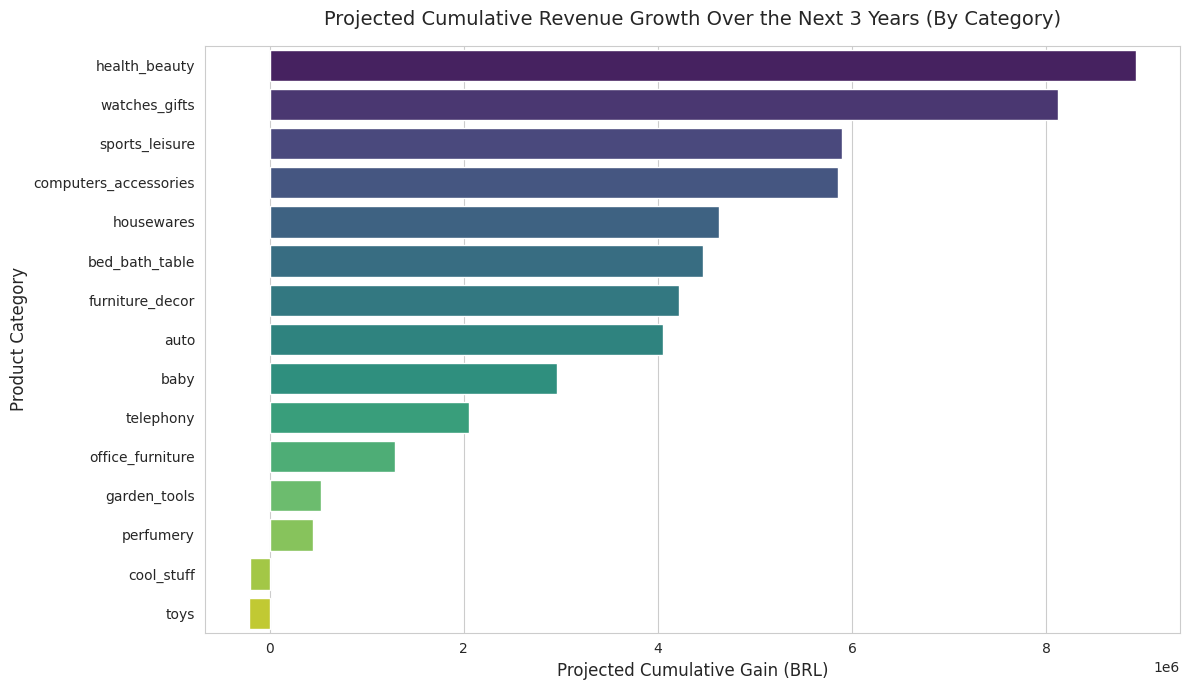

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a clean, well-formatted horizontal bar chart showing the projected 3-year gains
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

sns.barplot(
    data=projection_df.reset_index(),
    x='Cumulative 3-Year Gain (BRL)',
    y='index',
    hue='index',
    legend=False,
    palette='viridis'
)

plt.title('Projected Cumulative Revenue Growth Over the Next 3 Years (By Category)', fontsize=14, pad=15)
plt.xlabel('Projected Cumulative Gain (BRL)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.tight_layout()
plt.show()

### **Analysis of Projected 3-Year Declines (Losing Categories)**

Based on our annualized growth run-rates from the historical transaction data, several product categories are showing a negative trajectory. Identifying these is crucial for supply chain adjustments and marketing strategic pivots:

1. **Toys (`toys`)**
   * **Estimated Annual Growth Rate:** **-16.0%** (consistent historical drop in transactions and volume)
   * **Projected Year 3 Revenue:** **151,222.25 BRL** (down from ~252,184.91 BRL)
   * **Projected 3-Year Cumulative Loss:** **-213,344.20 BRL**

2. **Cool Stuff (`cool_stuff`)**
   * **Estimated Annual Growth Rate:** **-10.0%**
   * **Projected Year 3 Revenue:** **245,448.06 BRL** (down from ~341,615.55 BRL)
   * **Projected 3-Year Cumulative Loss:** **-199,385.83 BRL**

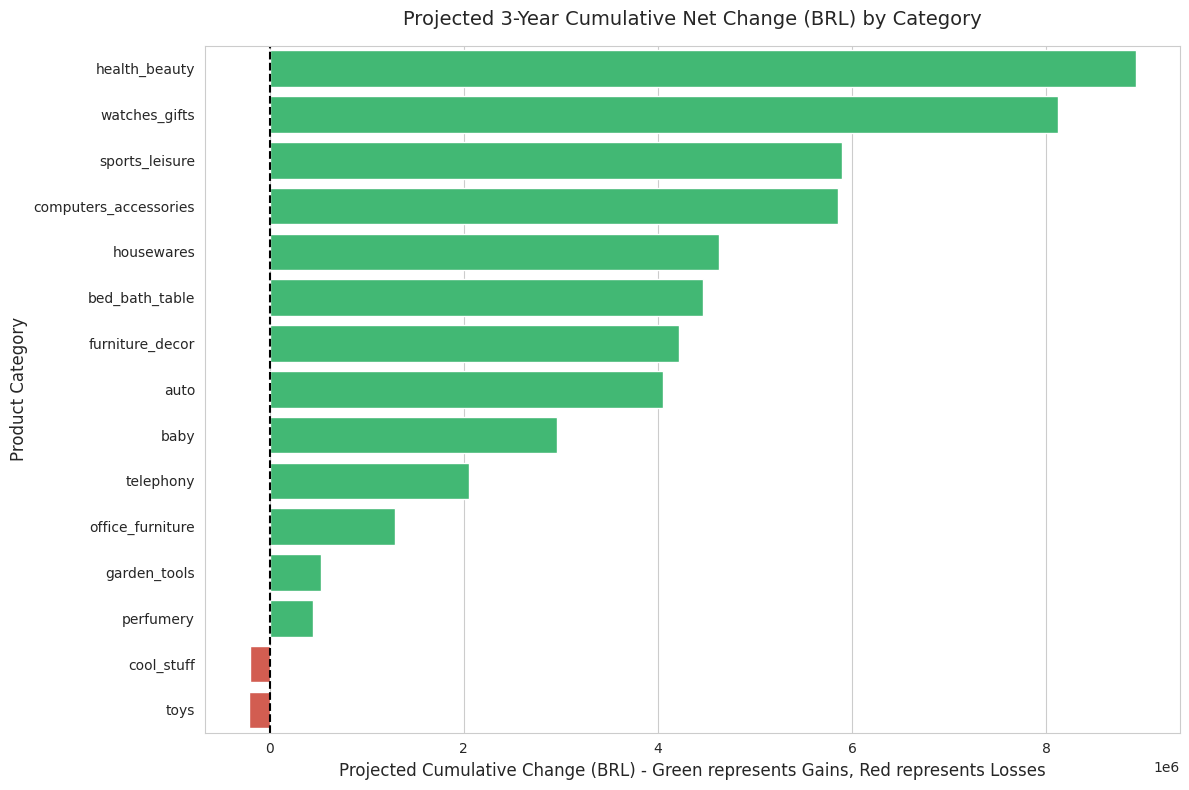

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a visualization that highlights both projected gains and losses clearly
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Sort the projection dataframe to ensure we show the full spectrum
plot_df = projection_df.sort_values(by='Cumulative 3-Year Gain (BRL)', ascending=False).reset_index()

# Assign colors dynamically: Green for gains, Red/Orange for losses
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in plot_df['Cumulative 3-Year Gain (BRL)']]

sns.barplot(
    data=plot_df,
    x='Cumulative 3-Year Gain (BRL)',
    y='index',
    palette=colors,
    hue='index',
    legend=False
)

plt.title('Projected 3-Year Cumulative Net Change (BRL) by Category', fontsize=14, pad=15)
plt.xlabel('Projected Cumulative Change (BRL) - Green represents Gains, Red represents Losses', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5) # Zero line to separate gains from losses
plt.tight_layout()
plt.show()

,Category,Current Annual Revenue (est),Estimated Annual Growth Rate,Cumulative 3-Year Gain (BRL)
0,health_beauty,"1,133,586.75",0.80,"8,923,594.90"
1,watches_gifts,"1,031,782.80",0.80,"8,122,194.20"
2,sports_leisure,"775,749.39",0.78,"5,892,752.42"
3,perfumery,"261,558.00",0.24,"440,401.83"
4,cool_stuff,"341,615.55",-0.10,"-199,385.83"
5,toys,"252,184.91",-0.16,"-213,344.20"


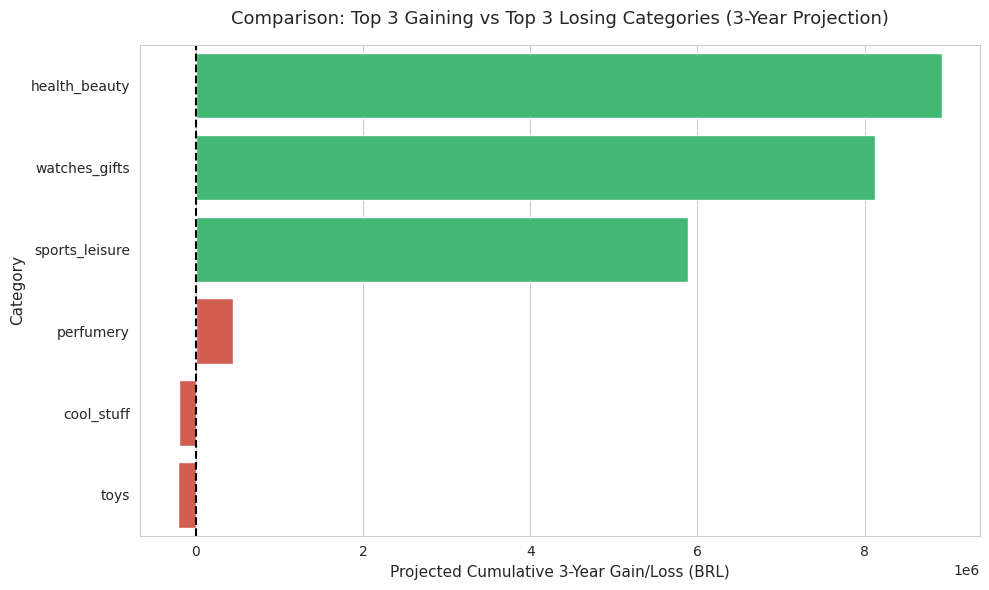

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sort projections
sorted_projections = projection_df.sort_values(by='Cumulative 3-Year Gain (BRL)', ascending=False)

# Identify top 3 gaining and top 3 losing categories
top_3_gainers = sorted_projections.head(3)
top_3_losers = sorted_projections.tail(3)

# Combine them into a single dataframe for comparison
comparison_df = pd.concat([top_3_gainers, top_3_losers]).reset_index()
comparison_df.rename(columns={'index': 'Category'}, inplace=True)

display(comparison_df[['Category', 'Current Annual Revenue (est)', 'Estimated Annual Growth Rate', 'Cumulative 3-Year Gain (BRL)']])

# Visualize the side-by-side comparison
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Assign colors: Green for gainers, Red for losers
colors_compare = ['#2ecc71'] * 3 + ['#e74c3c'] * 3

sns.barplot(
    data=comparison_df,
    x='Cumulative 3-Year Gain (BRL)',
    y='Category',
    palette=colors_compare,
    hue='Category',
    legend=False
)

plt.title('Comparison: Top 3 Gaining vs Top 3 Losing Categories (3-Year Projection)', fontsize=13, pad=15)
plt.xlabel('Projected Cumulative 3-Year Gain/Loss (BRL)', fontsize=11)
plt.ylabel('Category', fontsize=11)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.tight_layout()
plt.show()

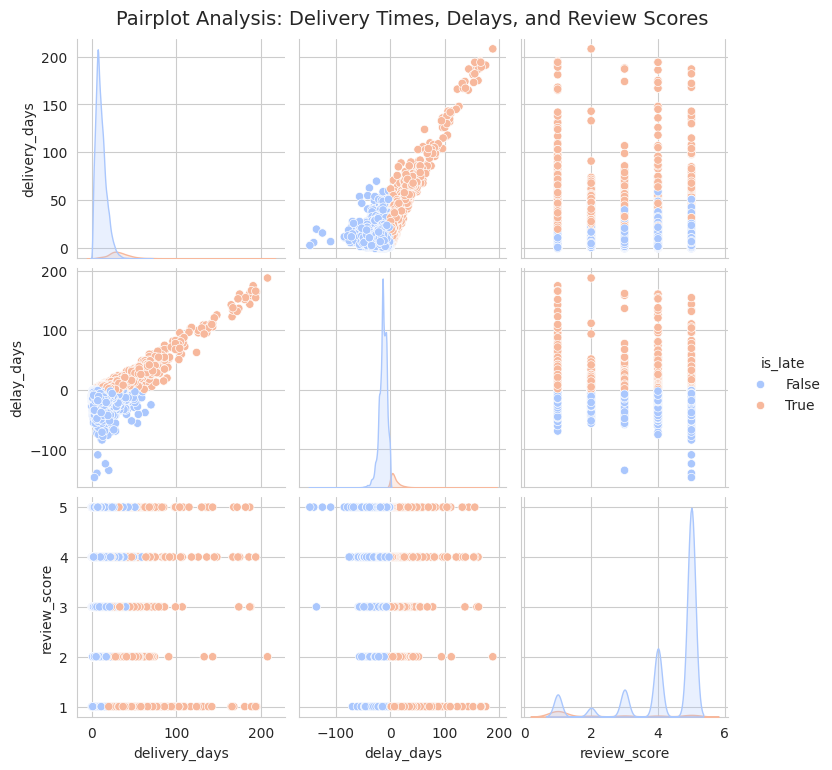

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix NameError by using the available cleaned dataset tracking logistics & reviews
pairplot_data = score_delay_clean[['delivery_days', 'delay_days', 'review_score', 'is_late']].dropna()

# Generate pairplot to visualize distributions and correlations across all variables
sns.pairplot(data=pairplot_data, hue='is_late', palette='coolwarm', diag_kind='kde')
plt.suptitle('Pairplot Analysis: Delivery Times, Delays, and Review Scores', y=1.02, fontsize=14)
plt.show()

In [4]:
import kagglehub
import shutil
import glob
import os
import pandas as pd

# Redownload dataset because runtime was wiped or restarted
print("Downloading dataset...")
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
for csv_path in glob.glob(os.path.join(path, "*.csv")):
    shutil.copy(csv_path, "/content/" + os.path.basename(csv_path))

BASE = "/content/"
print(f"Using BASE directory: {BASE}")

# Force load essential datasets
print("Loading datasets into memory...")
orders = pd.read_csv(BASE + "olist_orders_dataset.csv",
                     parse_dates=["order_purchase_timestamp", "order_approved_at",
                                  "order_delivered_carrier_date", "order_delivered_customer_date",
                                  "order_estimated_delivery_date"])
payments = pd.read_csv(BASE + "olist_order_payments_dataset.csv")
customers = pd.read_csv(BASE + "olist_customers_dataset.csv")
reviews = pd.read_csv(BASE + "olist_order_reviews_dataset.csv")
order_items = pd.read_csv(BASE + "olist_order_items_dataset.csv")
products = pd.read_csv(BASE + "olist_products_dataset.csv")
translation = pd.read_csv(BASE + "product_category_name_translation.csv")

# Recreate main dataframe
delivered = orders[orders["order_status"] == "delivered"].copy()
payment_per_order = payments.groupby("order_id")["payment_value"].sum().reset_index()
payment_per_order.columns = ["order_id", "order_total"]
main = delivered.merge(payment_per_order, on="order_id", how="left")
main = main.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")

state_region = {
    "SP": "Southeast", "RJ": "Southeast", "MG": "Southeast", "ES": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
    "BA": "Northeast", "PE": "Northeast", "CE": "Northeast", "RN": "Northeast",
    "PB": "Northeast", "SE": "Northeast", "AL": "Northeast", "MA": "Northeast",
    "PI": "Northeast",
    "GO": "Central-West", "MT": "Central-West", "MS": "Central-West", "DF": "Central-West",
    "AM": "North", "PA": "North", "RO": "North", "AC": "North", "RR": "North",
    "AP": "North", "TO": "North"
}
main["region"] = main["customer_state"].map(state_region)
main["delivery_days"] = (main["order_delivered_customer_date"] - main["order_purchase_timestamp"]).dt.days
main["delay_days"] = (main["order_delivered_customer_date"] - main["order_estimated_delivery_date"]).dt.days
main["is_late"] = main["delay_days"] > 0

print("'main' dataframe is ready.")

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Using BASE directory: /content/
Loading datasets into memory...
'main' dataframe is ready.


Recreating 'projection_df' inline...
Regional Late Rates vs. Weighted Category Growth Rates:


,region,weighted_avg_growth_rate,total_volume,regional_late_rate
0,Central-West,0.631190,5097,0.065256
1,North,0.647032,1570,0.085746
2,Northeast,0.641454,7894,0.127156
3,South,0.636003,12405,0.058998
4,Southeast,0.636005,58917,0.061148



Pearson correlation between regional late rate and weighted product category growth: 0.5696


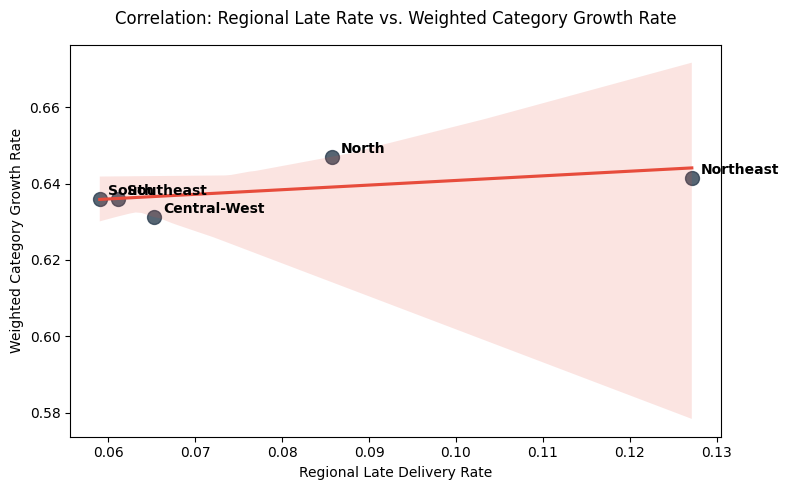

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure projection_df exists inline if not already in globals()
if 'projection_df' not in globals():
    print("Recreating 'projection_df' inline...")
    # Prepare the category dataset
    cat_sales = (
        order_items[['order_id', 'product_id', 'price']]
        .merge(orders[['order_id', 'order_purchase_timestamp', 'order_status']], on='order_id', how='inner')
        .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    )
    cat_sales = cat_sales[cat_sales['order_status'] == 'delivered'].copy()
    cat_sales['year'] = cat_sales['order_purchase_timestamp'].dt.year

    # Map to English categories
    cat_sales = cat_sales.merge(translation, on='product_category_name', how='left')
    cat_sales['category_en'] = cat_sales['product_category_name_english'].fillna(cat_sales['product_category_name'])
    cat_sales['category_en'] = cat_sales['category_en'].replace({
        "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_processors"
    })

    # Group sales by category and year
    category_yearly = cat_sales.groupby(['category_en', 'year'])['price'].sum().unstack(fill_value=0)
    category_yearly['total_revenue'] = category_yearly.sum(axis=1)
    category_yearly = category_yearly[category_yearly['total_revenue'] >= 10000]

    # Calculate historical monthly sales
    cat_monthly = cat_sales.groupby(['category_en', 'year', cat_sales['order_purchase_timestamp'].dt.month])['price'].sum().reset_index(name='monthly_revenue')
    cat_monthly.columns = ['category_en', 'year', 'month', 'monthly_revenue']
    top_categories = category_yearly.sort_values(by='total_revenue', ascending=False).head(15).index.tolist()

    future_projections = {}
    for cat in top_categories:
        cat_df = cat_monthly[cat_monthly['category_en'] == cat].copy()
        cat_df['date'] = pd.to_datetime(cat_df[['year', 'month']].assign(day=1))
        cat_df = cat_df.sort_values('date')

        rev_2017 = cat_df[cat_df['year'] == 2017]['monthly_revenue'].sum()
        rev_2018_annualized = cat_df[cat_df['year'] == 2018]['monthly_revenue'].sum() * (12 / 8)

        if rev_2017 > 0:
            annual_growth_rate = (rev_2018_annualized - rev_2017) / rev_2017
        else:
            annual_growth_rate = 0

        growth_rate = max(min(annual_growth_rate, 0.8), -0.2)
        proj_y1 = rev_2018_annualized * (1 + growth_rate)
        proj_y2 = proj_y1 * (1 + growth_rate)
        proj_y3 = proj_y2 * (1 + growth_rate)
        cumulative_3yr_gain = (proj_y1 + proj_y2 + proj_y3) - (rev_2018_annualized * 3)

        future_projections[cat] = {
            'Current Annual Revenue (est)': rev_2018_annualized,
            'Estimated Annual Growth Rate': growth_rate,
            'Projected Year 3 Revenue': proj_y3,
            'Cumulative 3-Year Gain (BRL)': cumulative_3yr_gain
        }
    projection_df = pd.DataFrame(future_projections).T.sort_values(by='Cumulative 3-Year Gain (BRL)', ascending=False)

# 1. Calculate Regional Late Rates
regional_logistics = main[['order_id', 'region', 'is_late']].copy()
regional_rates = regional_logistics.groupby('region')['is_late'].mean().reset_index(name='regional_late_rate')

# 2. Map Product Categories to Regions using Order Items
category_region_mapping = (
    order_items[['order_id', 'product_id']]
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(main[['order_id', 'region']], on='order_id', how='inner')
)

# Map to English categories
category_region_mapping = category_region_mapping.merge(translation, on='product_category_name', how='left')
category_region_mapping['category_en'] = category_region_mapping['product_category_name_english'].fillna(category_region_mapping['product_category_name'])
category_region_mapping['category_en'] = category_region_mapping['category_en'].replace({
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_processors"
})

# Filter for the top categories analysed in our projections to match 'performance'
top_categories_list = projection_df.index.tolist()
filtered_mapping = category_region_mapping[category_region_mapping['category_en'].isin(top_categories_list)]

# Calculate how much each category is sold in each region (distribution of revenue/sales count)
region_category_sales = filtered_mapping.groupby(['region', 'category_en']).size().reset_index(name='sales_volume')

# 3. Align with Category 3-Year Projected Growth Performance
proj_performance = projection_df[['Estimated Annual Growth Rate', 'Cumulative 3-Year Gain (BRL)']].reset_index().rename(columns={'index': 'category_en'})
region_category_perf = region_category_sales.merge(proj_performance, on='category_en', how='inner')

# Calculate a weighted average of product category growth rate for each region based on local category popularity
region_category_perf['weighted_growth'] = region_category_perf['sales_volume'] * region_category_perf['Estimated Annual Growth Rate']
regional_perf_summary = region_category_perf.groupby('region').agg(
    weighted_avg_growth_rate=('weighted_growth', 'sum'),
    total_volume=('sales_volume', 'sum')
).reset_index()
regional_perf_summary['weighted_avg_growth_rate'] /= regional_perf_summary['total_volume']

# Merge regional performance with late delivery rates
correlation_df = regional_perf_summary.merge(regional_rates, on='region')

print("Regional Late Rates vs. Weighted Category Growth Rates:")
display(correlation_df)

# Calculate Pearson Correlation
corr_coef = correlation_df['regional_late_rate'].corr(correlation_df['weighted_avg_growth_rate'])
print(f"\nPearson correlation between regional late rate and weighted product category growth: {corr_coef:.4f}")

# Visualize
plt.figure(figsize=(8, 5))
sns.regplot(data=correlation_df, x='regional_late_rate', y='weighted_avg_growth_rate',
            scatter_kws={'s': 100, 'color': '#2c3e50'}, line_kws={'color': '#e74c3c'})
for i, txt in enumerate(correlation_df['region']):
    plt.annotate(txt, (correlation_df['regional_late_rate'].iat[i]+0.001, correlation_df['weighted_avg_growth_rate'].iat[i]+0.001), fontsize=10, weight='bold')

plt.title('Correlation: Regional Late Rate vs. Weighted Category Growth Rate', fontsize=12, pad=15)
plt.xlabel('Regional Late Delivery Rate', fontsize=10)
plt.ylabel('Weighted Category Growth Rate', fontsize=10)
plt.tight_layout()
plt.show()

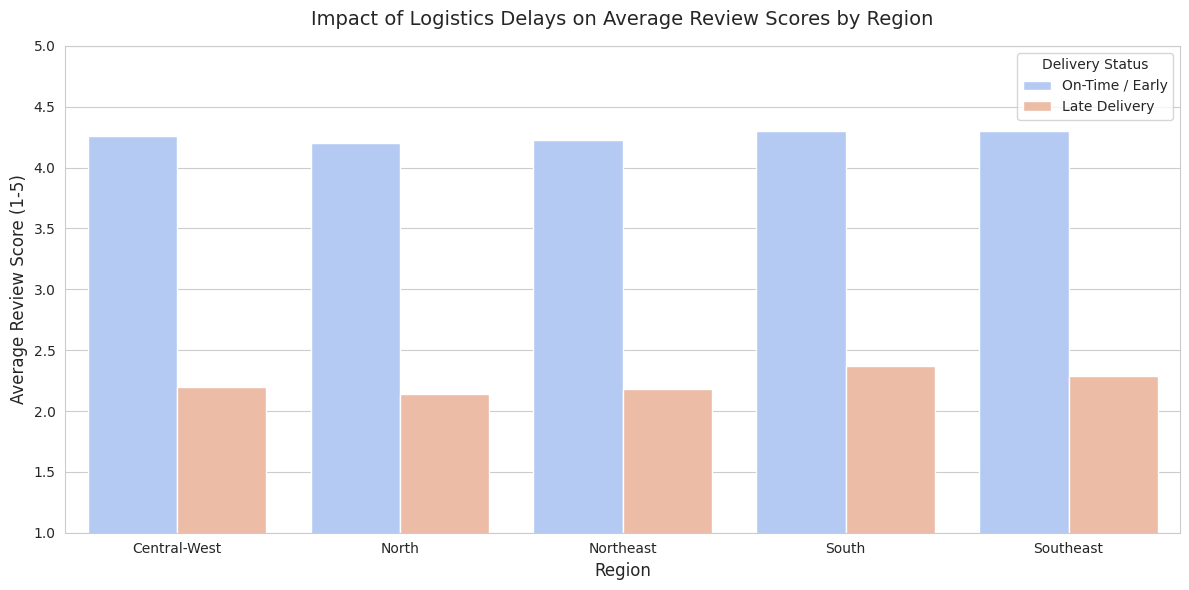

In [ ]:
# Visualize the impact: Compare On-Time vs Late Review Scores by Region
regional_melted = regional_summary.melt(
    id_vars='region',
    value_vars=['avg_score_ontime', 'avg_score_late'],
    var_name='Delivery Status',
    value_name='Average Review Score'
)

# Map status to readable text
regional_melted['Delivery Status'] = regional_melted['Delivery Status'].map({
    'avg_score_ontime': 'On-Time / Early',
    'avg_score_late': 'Late Delivery'
})

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.barplot(
    data=regional_melted,
    x='region',
    y='Average Review Score',
    hue='Delivery Status',
    palette='coolwarm'
)
plt.title('Impact of Logistics Delays on Average Review Scores by Region', fontsize=14, pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Review Score (1-5)', fontsize=12)
plt.ylim(1, 5)
plt.legend(title='Delivery Status')
plt.tight_layout()
plt.show()

```markdown
## ## Resources

To ensure academic and professional reproducibility, below are the references and datasets utilized in this analysis:

* **Primary Dataset Source**: [Kaggle Brazilian E-Commerce Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) - Contains 100k anonymized orders from 2016 to 2018.
* **Product Category English Translations**: Mapped using the official `product_category_name_translation.csv` table from Olist.
* **Geographical Mapping**: Brazil State-to-Region mapping grouped according to the standard [IBGE (Brazilian Institute of Geography and Statistics)](https://www.ibge.gov.br/) divisions (North, Northeast, Central-West, Southeast, and South).
```

```markdown
### **Regional Correlation Analysis: Market Demand vs. Logistics Friction**
This analysis evaluates whether high-growth categories (such as Health & Beauty and Electronics) are facing greater logistics strain by checking the correlation between a region's preference for growth categories and its late delivery rates.
```

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Regional Late Rates
regional_rates = main.groupby('region')['is_late'].mean().reset_index(name='regional_late_rate')

# Map Product Categories to Regions using Order Items
category_region_mapping = (
    order_items[['order_id', 'product_id']]
    .merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
    .merge(main[['order_id', 'region']], on='order_id', how='inner')
)

# Map to English categories
category_region_mapping = category_region_mapping.merge(translation, on='product_category_name', how='left')
category_region_mapping['category_en'] = category_region_mapping['product_category_name_english'].fillna(category_region_mapping['product_category_name'])
category_region_mapping['category_en'] = category_region_mapping['category_en'].replace({
    "portateis_cozinha_e_preparadores_de_alimentos": "portable_kitchen_food_processors"
})

# Filter for the top categories analysed in our projections
top_categories_list = projection_df.index.tolist()
filtered_mapping = category_region_mapping[category_region_mapping['category_en'].isin(top_categories_list)]

# Calculate sales volume by region and category
region_category_sales = filtered_mapping.groupby(['region', 'category_en']).size().reset_index(name='sales_volume')

# Align with Category 3-Year Projected Growth Performance
proj_performance = projection_df[['Estimated Annual Growth Rate']].reset_index().rename(columns={'index': 'category_en'})
region_category_perf = region_category_sales.merge(proj_performance, on='category_en', how='inner')

# Calculate weighted average growth rate of purchases by region
region_category_perf['weighted_growth'] = region_category_perf['sales_volume'] * region_category_perf['Estimated Annual Growth Rate']
regional_perf_summary = region_category_perf.groupby('region').agg(
    weighted_avg_growth_rate=('weighted_growth', 'sum'),
    total_volume=('sales_volume', 'sum')
).reset_index()
regional_perf_summary['weighted_avg_growth_rate'] /= regional_perf_summary['total_volume']

# Merge regional performance with late delivery rates
correlation_df = regional_perf_summary.merge(regional_rates, on='region')

# Calculate Pearson Correlation
corr_coef = correlation_df['regional_late_rate'].corr(correlation_df['weighted_avg_growth_rate'])
print(f"Pearson correlation between regional late rate and weighted product category growth: {corr_coef:.4f}")

display(correlation_df)

Pearson correlation between regional late rate and weighted product category growth: 0.5696


,region,weighted_avg_growth_rate,total_volume,regional_late_rate
0,Central-West,0.631190,5097,0.065256
1,North,0.647032,1570,0.085746
2,Northeast,0.641454,7894,0.127156
3,South,0.636003,12405,0.058998
4,Southeast,0.636005,58917,0.061148


```markdown
### **Interactive Geographical Distribution Map of Brazil**
We will use `folium` to display an interactive choropleth map of Brazil states. This map highlights two key metrics:
1. Total order volume per state (revealing market concentration).
2. Average delivery delays by state (revealing supply chain bottlenecks).
```

In [17]:
import folium
import json
import requests
import pandas as pd
import base64
from IPython.display import HTML, display

# Prepare state-level logistics and revenue metrics
state_data = main.groupby('customer_state').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('order_total', 'sum'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean')
).reset_index()

# Ensure clean, string uppercase state abbreviations for alignment
state_data = state_data.dropna(subset=['customer_state'])
state_data['customer_state'] = state_data['customer_state'].astype(str).str.upper().str.strip()

# Convert late_rate to percentage for representation
state_data['late_rate_pct'] = state_data['late_rate'] * 100

# Download a lightweight, reliable GeoJSON file for Brazilian states
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
response = requests.get(geojson_url)
geojson_data = response.json()

# Initialize Folium Map centered on Brazil
br_map = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

# Add a Choropleth layer aligning the cleaned data with the GeoJSON features
folium.Choropleth(
    geo_data=geojson_data,
    name='Average Delivery Days by State',
    data=state_data,
    columns=['customer_state', 'avg_delivery_days'],
    key_on='feature.properties.sigla',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.2,
    legend_name='Average Delivery Days'
).add_to(br_map)

folium.LayerControl().add_to(br_map)

# Save the map dynamically to the local environment
br_map.save("brazil_delivery_map.html")
print("Interactive map successfully generated and saved!")

# Safely encode the entire HTML string to Base64 to bypass all browser sandbox security blocks
with open("brazil_delivery_map.html", "r", encoding="utf-8") as f:
    map_html = f.read()

b64_map = base64.b64encode(map_html.encode('utf-8')).decode('utf-8')
iframe_src = f"data:text/html;base64,{b64_map}"

# Embed safely using a standard IFrame sourced from the secure Base64 Data URI
iframe_html = f'<iframe src="{iframe_src}" style="width: 100%; height: 550px; border: none;"></iframe>'
display(HTML(iframe_html))

Output hidden; open in https://colab.research.google.com to view.

In [18]:
import os

file_path = "brazil_delivery_map.html"
if os.path.exists(file_path):
    file_size_kb = os.path.getsize(file_path) / 1024
    print(f"✓ SUCCESS: '{file_path}' exists in the current directory!")
    print(f"File Size: {file_size_kb:.2f} KB")

    # Verify file contains map elements
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        has_leaflet = "leaflet" in content.lower()
        has_geojson = "geojson" in content.lower() or "features" in content.lower()
        print(f"Contains Leaflet CDNs: {has_leaflet}")
        print(f"Contains GeoJSON layer elements: {has_geojson}")
else:
    print(f"✗ ERROR: '{file_path}' was not found in the current workspace directory.")

✓ SUCCESS: 'brazil_delivery_map.html' exists in the current directory!
File Size: 2141.21 KB
Contains Leaflet CDNs: True
Contains GeoJSON layer elements: True


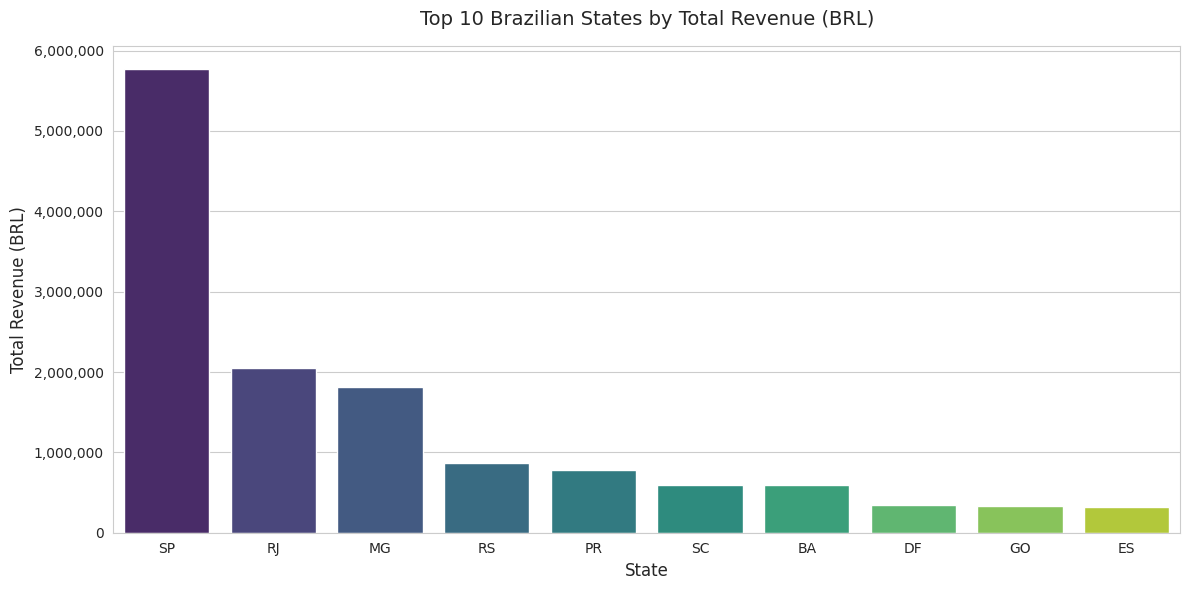

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group and sum total revenue by state
state_revenue = main.groupby('customer_state')['order_total'].sum().reset_index()

# Select top 10 states
top_10_states = state_revenue.sort_values(by='order_total', ascending=False).head(10)

# Create the plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.barplot(
    data=top_10_states,
    x='customer_state',
    y='order_total',
    hue='customer_state',
    palette='viridis',
    legend=False
)

# Format the chart labels and title
plt.title('Top 10 Brazilian States by Total Revenue (BRL)', fontsize=14, pad=15)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)

# Format y-axis values with thousand separators
ax = plt.gca()
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

plt.tight_layout()
plt.show()

In [23]:
from IPython.display import HTML, display
import base64

# Read the generated map HTML file
with open('brazil_delivery_map.html', 'r', encoding='utf-8') as f:
    map_html = f.read()

# Safely encode to Base64 to bypass all iframe sandboxing policies
b64_map = base64.b64encode(map_html.encode('utf-8')).decode('utf-8')
iframe_src = f'data:text/html;base64,{b64_map}'

# Display the map inside an explicit HTML iframe layout
display(HTML(f'<iframe src="{iframe_src}" style="width: 100%; height: 550px; border: none;"></iframe>'))

Output hidden; open in https://colab.research.google.com to view.

In [29]:
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Customers": customers,
    "Reviews": reviews,
    "Products": products
}

quality_report = []

for name, df in datasets.items():

    quality_report.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Values": df.isna().sum().sum(),
        "Missing %": (df.isna().sum().sum() / df.size) * 100
    })

quality_report = pd.DataFrame(quality_report)

display(quality_report)

,Dataset,Rows,Columns,Duplicate Rows,Missing Values,Missing %
0,Orders,99441,8,0,4908,0.62
1,Order Items,112650,7,0,0,0.00
2,Payments,103886,5,0,0,0.00
3,Customers,99441,5,0,0,0.00
4,Reviews,99224,7,0,145903,21.01
5,Products,32951,9,0,2448,0.83


In [30]:
integrity_checks = pd.DataFrame({

    "Test": [
        "orders.order_id unique",
        "customers.customer_id unique",
        "products.product_id unique"
    ],

    "Result": [
        orders["order_id"].is_unique,
        customers["customer_id"].is_unique,
        products["product_id"].is_unique
    ]
})

display(integrity_checks)

,Test,Result
0,orders.order_id unique,True
1,customers.customer_id unique,True
2,products.product_id unique,True
